<a href="https://colab.research.google.com/github/lukasakar19-byte/Analisis-Regresi/blob/main/Projek_AnReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import os
import pandas as pd

from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/MRA/Tugas/datania1k.csv")
data.info()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   Gender                1000 non-null   object 
 2   Age                   1000 non-null   int64  
 3   Driving_License       1000 non-null   int64  
 4   Region_Code           1000 non-null   float64
 5   Previously_Insured    1000 non-null   int64  
 6   Vehicle_Age           1000 non-null   object 
 7   Vehicle_Damage        1000 non-null   object 
 8   Annual_Premium        1000 non-null   float64
 9   Policy_Sales_Channel  1000 non-null   float64
 10  Vintage               1000 non-null   int64  
 11  Response              1000 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory us

In [33]:
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,100000,Male,22,1,8.0,0,< 1 Year,Yes,36513.0,160.0,189,0
1,100001,Male,24,1,36.0,0,< 1 Year,Yes,2630.0,160.0,268,0
2,100002,Female,22,1,15.0,0,< 1 Year,Yes,35832.0,152.0,289,0
3,100003,Male,72,1,28.0,0,> 2 Years,Yes,36685.0,26.0,113,0
4,100004,Male,66,1,28.0,0,> 2 Years,Yes,2630.0,45.0,123,1


In [34]:
data.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
995,100995,Male,47,1,37.0,0,1-2 Year,Yes,29384.0,152.0,233,0
996,100996,Male,56,1,8.0,1,1-2 Year,No,47479.0,26.0,189,0
997,100997,Male,22,1,28.0,1,< 1 Year,No,29000.0,152.0,231,0
998,100998,Female,48,1,28.0,0,1-2 Year,Yes,45107.0,124.0,239,0
999,100999,Male,33,1,8.0,0,< 1 Year,Yes,43068.0,157.0,188,0


In [35]:
import pandas as pd
X = data[['Annual_Premium']]
y = data['Response']

# Combine X and Y into a new DataFrame
df = pd.concat([X, y], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Premium  1000 non-null   float64
 1   Response        1000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coef = model.coef_[0]

print("Intercept :", intercept)
print("Koefisien :", coef)
print("\nPersamaan Regresi:")
print("Response =", intercept, "+", coef, "* Annual_Premium")

Intercept : 0.08605580016556096
Koefisien : 9.201590625183517e-07

Persamaan Regresi:
Response = 0.08605580016556096 + 9.201590625183517e-07 * Annual_Premium


In [38]:
fitted = model.predict(X_train)
residual = y_train - fitted

In [39]:
from scipy import stats

shapiro_test = stats.shapiro(residual)

print("Shapiro-Wilk Test")
print("Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

Shapiro-Wilk Test
Statistic: 0.4111003779285457
p-value: 5.83765868110107e-45


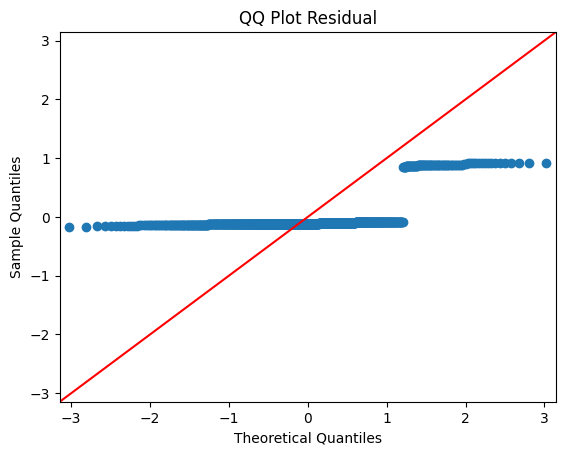

In [40]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

sm.qqplot(residual, line='45')
plt.title("QQ Plot Residual")
plt.show()

In [41]:
from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm

X_sm = sm.add_constant(X_train)
bp_test = het_breuschpagan(residual, X_sm)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(1.5606505969831375), 'LM-Test p-value': np.float64(0.21156998579046926), 'F-Statistic': np.float64(1.5597918330599583), 'F-Test p-value': np.float64(0.21206194179978746)}


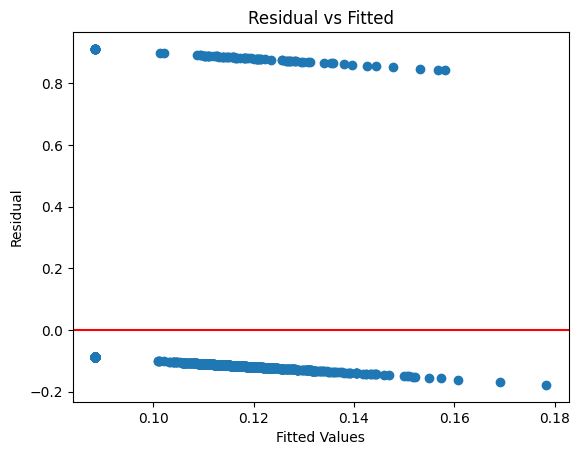

In [42]:
plt.scatter(fitted, residual)
plt.axhline(y=0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual vs Fitted")
plt.show()

In [43]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)

print("Durbin Watson:", dw)

Durbin Watson: 1.902479289423809


In [45]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())
print("Nilai R-squared:", r2)

                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.157
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.282
Time:                        13:49:58   Log-Likelihood:                -304.95
No. Observations:                1000   AIC:                             613.9
Df Residuals:                     998   BIC:                             623.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1022      0.022      4.